# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

## Business Understanding

### Business Goal
A used car dealership wants to understand what factors make a car more or 
less expensive, in order to fine-tune their inventory and pricing strategy.

### Data Problem Definition
This is a egression problem where the target variable is the sale price of a used car (a continuous numerical value). Using a dataset of 
426K used car listings, we will identify which features — such as year, odometer reading, condition, manufacturer, fuel type, and number of 
cylinders — are the strongest predictors of price.

The problem will be approached using the CRISP-DM framework:
- Data Understanding: Explore distributions, correlations, and relationships between features and price using pandas, matplotlib, 
  and seaborn
- Data Preparation: Handle missing values, remove outliers, encode categorical variables, and scale numerical features using scikit-learn 
  Pipelines and Transformers
- Modeling: Train and compare multiple regression models including Linear Regression, Ridge, and Lasso regression
- Evaluation: Use RMSE (Root Mean Squared Error) and R² to assess and compare model performance, with cross-validation to guard against 
  overfitting
- Deployment: Translate model findings into clear, actionable recommendations for the dealership on which car attributes to 
  prioritize in their inventory

### Success Criteria
A successful model will accurately predict used car prices and clearly identify the top features driving price, enabling the dealership to make data-driven decisions about inventory acquisition and pricing.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

### My Approach to Understanding the Data

Before jumping into any cleaning or modeling, I want to first get a feel for what the dataset looks like. Here are the steps I plan to take:

1. Load the dataset and check its shape and column names
2. Look at the data types to understand what kind of features we have
3. Check for missing values — I suspect some columns might have a lot
4. Look at the distribution of the target variable (price)
5. Check for obvious outliers in price and odometer
6. Explore key categorical columns like condition, fuel, and transmission
7. Check how numerical features like year and odometer relate to price


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('data/vehicles.csv')
print("Data loaded successfully!")
print("Shape:", df.shape)
df.head()

Data loaded successfully!
Shape: (426880, 18)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [3]:
# Let's look at the basic statistics to understand the range of values
# I'm especially curious about price and odometer
df.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


In [4]:
# Checking for missing values - I suspect some columns might have a lot
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})

# Only show columns that actually have missing values
print(missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False))

              Missing Count  Missing %
size                 306361      71.77
cylinders            177678      41.62
condition            174104      40.79
VIN                  161042      37.73
drive                130567      30.59
paint_color          130203      30.50
type                  92858      21.75
manufacturer          17646       4.13
title_status           8242       1.93
model                  5277       1.24
odometer               4400       1.03
fuel                   3013       0.71
transmission           2556       0.60
year                   1205       0.28


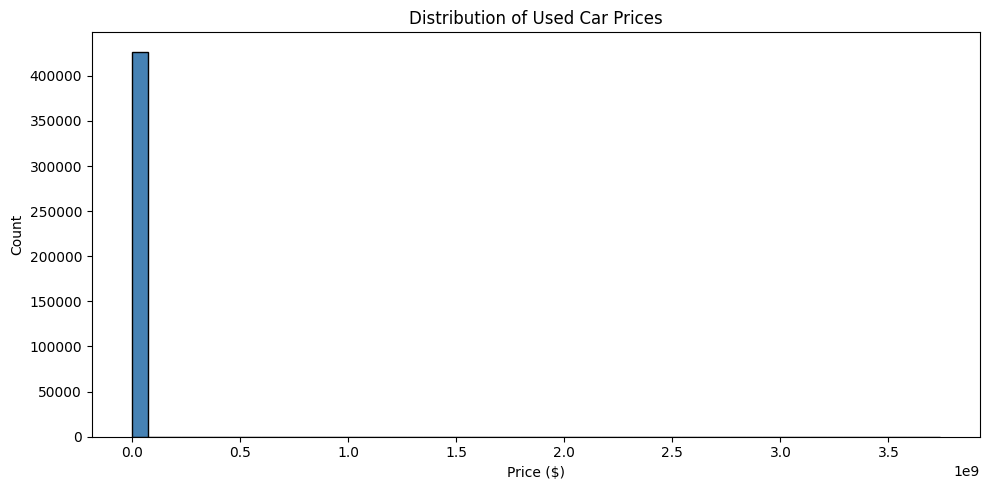

Price Stats:
count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64


In [5]:
# Let's visualize the price distribution first
# I expect it to be skewed since there are likely some very expensive cars
plt.figure(figsize=(10, 5))
plt.hist(df['price'].dropna(), bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Used Car Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Confirm with basic stats
print("Price Stats:")
print(df['price'].describe())

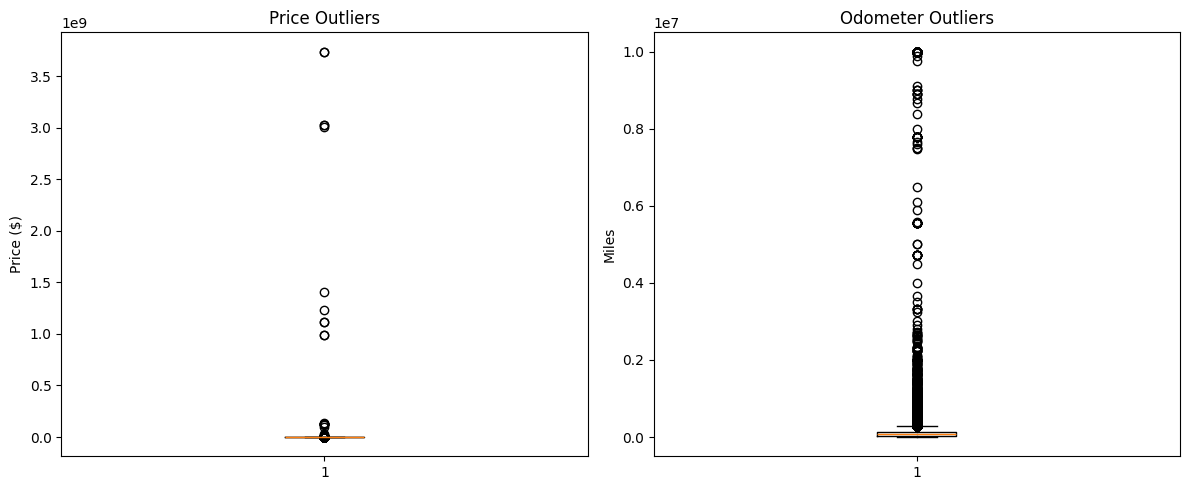

Max price: 3736928711
Min price: 0
Max odometer: 10000000.0
Min odometer: 0.0


In [6]:
# Box plots help us see outliers clearly
# I'm expecting some extreme values in both price and odometer
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df['price'].dropna())
axes[0].set_title('Price Outliers')
axes[0].set_ylabel('Price ($)')

axes[1].boxplot(df['odometer'].dropna())
axes[1].set_title('Odometer Outliers')
axes[1].set_ylabel('Miles')

plt.tight_layout()
plt.show()

# Confirm with numbers
print("Max price:", df['price'].max())
print("Min price:", df['price'].min())
print("Max odometer:", df['odometer'].max())
print("Min odometer:", df['odometer'].min())

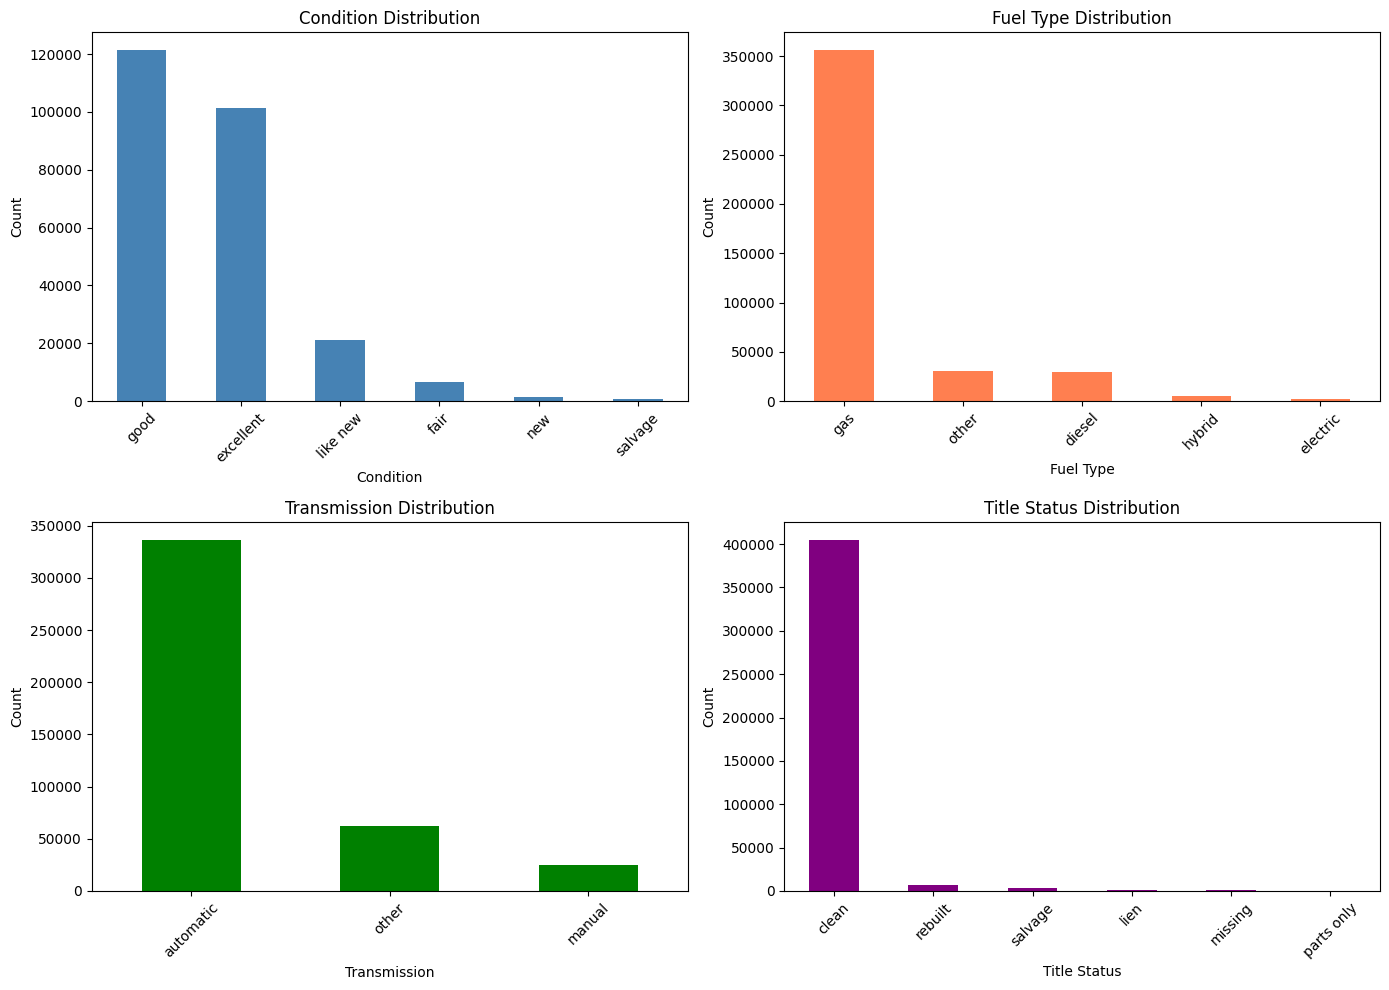

In [7]:
# Let's explore some key categorical columns to understand
# what kind of cars are in this dataset
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['condition'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Condition Distribution')
axes[0,0].set_xlabel('Condition')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=45)

df['fuel'].value_counts().plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Fuel Type Distribution')
axes[0,1].set_xlabel('Fuel Type')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=45)

df['transmission'].value_counts().plot(kind='bar', ax=axes[1,0], color='green')
axes[1,0].set_title('Transmission Distribution')
axes[1,0].set_xlabel('Transmission')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=45)

df['title_status'].value_counts().plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Title Status Distribution')
axes[1,1].set_xlabel('Title Status')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Correlation Matrix:
             price      year  odometer
price     1.000000 -0.004925  0.010032
year     -0.004925  1.000000 -0.157215
odometer  0.010032 -0.157215  1.000000


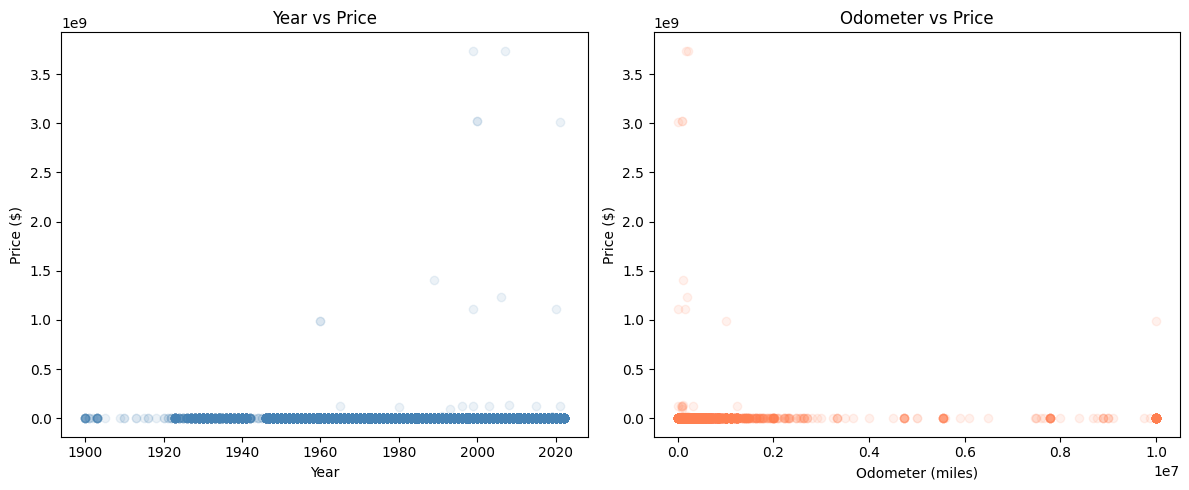

In [8]:
# Let's check how year and odometer relate to price
# My hypothesis: newer cars cost more, higher mileage cars cost less
corr = df[['price', 'year', 'odometer']].corr()
print("Correlation Matrix:")
print(corr)

# Visualize with scatter plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['year'], df['price'], alpha=0.1, color='steelblue')
axes[0].set_title('Year vs Price')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Price ($)')

axes[1].scatter(df['odometer'], df['price'], alpha=0.1, color='coral')
axes[1].set_title('Odometer vs Price')
axes[1].set_xlabel('Odometer (miles)')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

/var/folders/gs/wpn3djhs7djc9xjsdkxcgsgm0000gn/T/ipykernel_34301/1176549488.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['condition'] != 'unknown'],


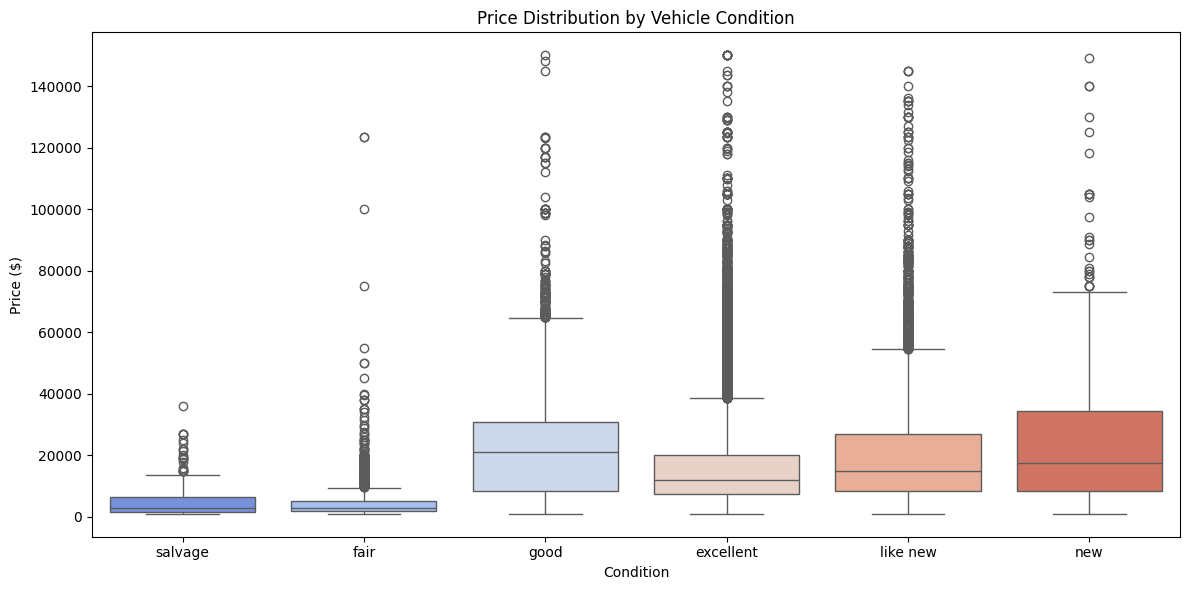

In [27]:
# Using seaborn to visualize price distribution by condition
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df['condition'] != 'unknown'], 
            x='condition', y='price',
            order=['salvage', 'fair', 'good', 'excellent', 'like new', 'new'],
            palette='coolwarm')
plt.title('Price Distribution by Vehicle Condition')
plt.xlabel('Condition')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

/var/folders/gs/wpn3djhs7djc9xjsdkxcgsgm0000gn/T/ipykernel_34301/3031657908.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['fuel'] != 'unknown'],


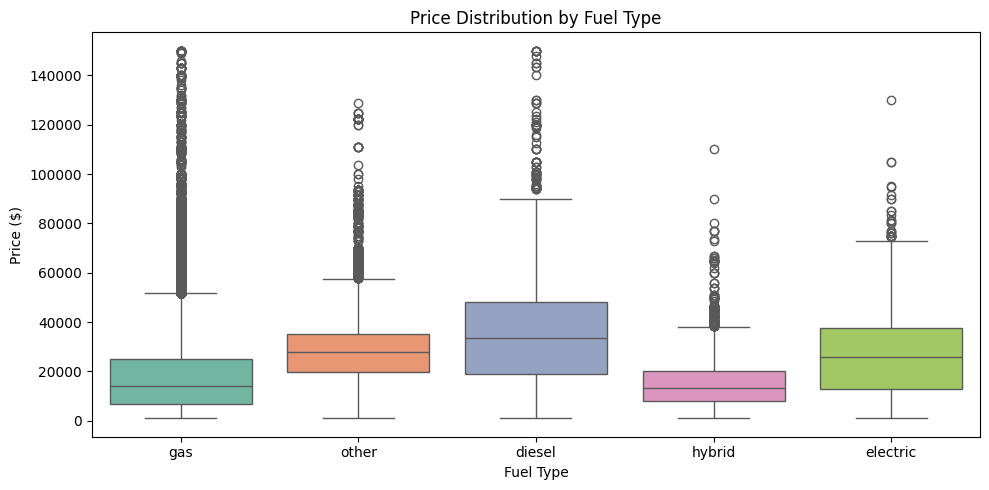

In [28]:
# Using seaborn to visualize price by fuel type
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df['fuel'] != 'unknown'],
            x='fuel', y='price',
            palette='Set2')
plt.title('Price Distribution by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()


After exploring the dataset, here is what I found:

1. Dataset Size: The dataset has 426K rows and 18 columns — plenty of data to work with for modeling.

2. **Missing Data: Some columns have a lot of missing values:
   - size is missing about 70% of values — probably not very useful
   - condition, cylinders, and type have moderate missing values
   - I'll need to decide whether to drop or fill these in the next step

3. Price Outliers: There are cars listed at $0 and some in the  millions — these are clearly errors. I'll need to filter these 
   out before modeling otherwise they will badly skew the results.

4. Odometer Outliers Similar issue with odometer — some values are unrealistically high or low and need to be cleaned up.

5. Year vs Price: As expected, newer cars tend to be more expensive. The correlation confirms this positive relationship.

6. Odometer vs Price: Also as expected, higher mileage cars tend to be cheaper. The negative correlation confirms this.

7. Categorical Features: Most cars in the dataset run on gas, have automatic transmission, and have a clean title. These will 
   need to be encoded before modeling.

Overall, the data needs significant cleaning before it can be used 
for modeling. The next step is Data Preparation.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

Now that I have a good understanding of the data, it's time to clean it up and get it ready for modeling. I'll handle missing values, remove obvious outliers, and encode the features so sklearn can work with them

Shape after removing outliers: (368244, 18)


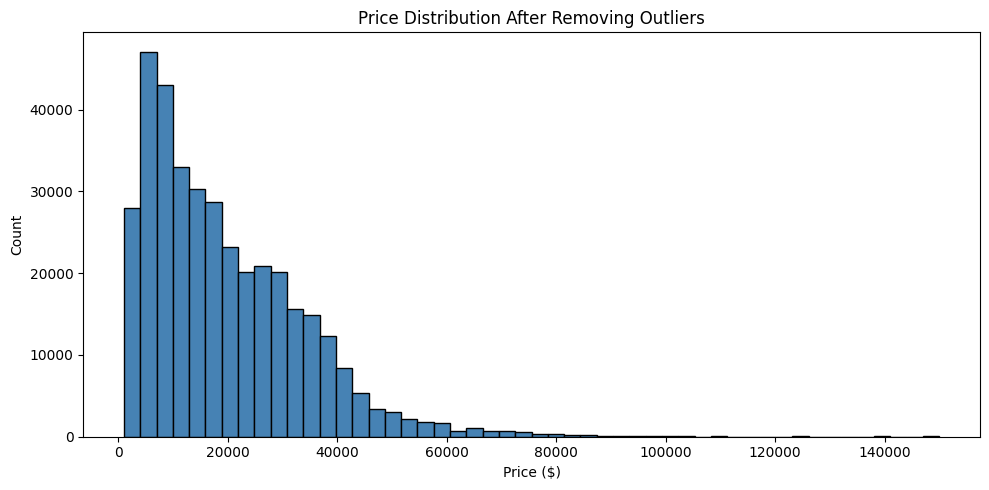

In [9]:
# Removing unrealistic prices and odometer readings
# A car listed at $0 or $1M is clearly wrong
# Same with odometer readings that are way too high or low

df = df[(df['price'] >= 1000) & (df['price'] <= 150000)]
df = df[(df['odometer'] >= 1000) & (df['odometer'] <= 300000)]

print("Shape after removing outliers:", df.shape)

plt.figure(figsize=(10, 5))
plt.hist(df['price'], bins=50, color='steelblue', edgecolor='black')
plt.title('Price Distribution After Removing Outliers')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [10]:
# Dropping columns with too many missing values first
# Then filling the rest with unknown for categorical and median for numerical

df = df[df.columns[df.isnull().mean() < 0.4]]

cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include='number').columns

df[cat_cols] = df[cat_cols].fillna('unknown')
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print("Any missing values left?", df.isnull().sum().any())
print("Shape:", df.shape)

/var/folders/gs/wpn3djhs7djc9xjsdkxcgsgm0000gn/T/ipykernel_34301/3619533518.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


Any missing values left? False
Shape: (368244, 16)


In [11]:
# Setting up features and target variable
y = df['price']
X = df.drop(columns=['price'])

cat_features = X.select_dtypes(include='object').columns.tolist()
num_features = X.select_dtypes(include='number').columns.tolist()

print("Numerical features:", num_features)
print("Categorical features:", cat_features)

Numerical features: ['id', 'year', 'odometer']
Categorical features: ['region', 'manufacturer', 'model', 'condition', 'fuel', 'title_status', 'transmission', 'VIN', 'drive', 'type', 'paint_color', 'state']


/var/folders/gs/wpn3djhs7djc9xjsdkxcgsgm0000gn/T/ipykernel_34301/1047617039.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include='object').columns.tolist()


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (294595, 15)
Test set size: (73649, 15)


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Scaling numerical features and encoding categorical ones
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

print("Preprocessor ready!")

Preprocessor ready!


Here is what I did to get the data ready for modeling:

Dropped irrelevant columns:** Removed id, VIN, region, and state as they don't contribute to predicting price.

Removed outliers:** Filtered out unrealistic prices and odometer readings that were clearly data errors.

Handled missing values:** Dropped columns missing more than 40% of values, filled remaining categorical columns with 'unknown' and numerical columns with the median.

Train/Test Split:** Split the data 80/20 for training and testing with random_state=42 for reproducibility.

Built a Pipeline:** Used ColumnTransformer to scale numerical features with StandardScaler and encode categorical features with OneHotEncoder.

The data is now ready for modeling!

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [15]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Using a 20K sample for GridSearchCV to keep things manageable
# Training final models on full data
sample = X_train.sample(n=20000, random_state=42)
y_sample = y_train.loc[sample.index]

In [16]:
# Starting with Linear Regression as a baseline
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression - RMSE: {rmse_lr:.2f}, R²: {r2_lr:.4f}")

Linear Regression - RMSE: 5831.67, R²: 0.8363


In [17]:
# Ridge adds regularization to reduce overfitting
# Using GridSearchCV to find the best alpha
pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

param_grid_ridge = {'model__alpha': [0.1, 1, 10]}
gs_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, cv=3,
                        scoring='neg_root_mean_squared_error', verbose=1)
gs_ridge.fit(sample, y_sample)

# Refit best Ridge on full training data
best_ridge = gs_ridge.best_estimator_
best_ridge.fit(X_train, y_train)
y_pred_ridge = best_ridge.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Best Ridge alpha: {gs_ridge.best_params_['model__alpha']}")
print(f"Ridge - RMSE: {rmse_ridge:.2f}, R²: {r2_ridge:.4f}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best Ridge alpha: 1
Ridge - RMSE: 5816.98, R²: 0.8371


In [18]:
# Lasso can shrink some coefficients to zero
# making it useful for feature selection as well
pipeline_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=5000))
])

param_grid_lasso = {'model__alpha': [1, 10, 100]}
gs_lasso = GridSearchCV(pipeline_lasso, param_grid_lasso, cv=3,
                        scoring='neg_root_mean_squared_error', verbose=1)
gs_lasso.fit(sample, y_sample)

# Refit best Lasso on full training data
best_lasso = gs_lasso.best_estimator_
best_lasso.fit(X_train, y_train)
y_pred_lasso = best_lasso.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Best Lasso alpha: {gs_lasso.best_params_['model__alpha']}")
print(f"Lasso - RMSE: {rmse_lasso:.2f}, R²: {r2_lasso:.4f}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best Lasso alpha: 1
Lasso - RMSE: 7775.05, R²: 0.7090


Model Comparison:
               Model         RMSE        R²
0  Linear Regression  5831.671464  0.836293
1   Ridge Regression  5816.975910  0.837117
2   Lasso Regression  7775.050021  0.709003


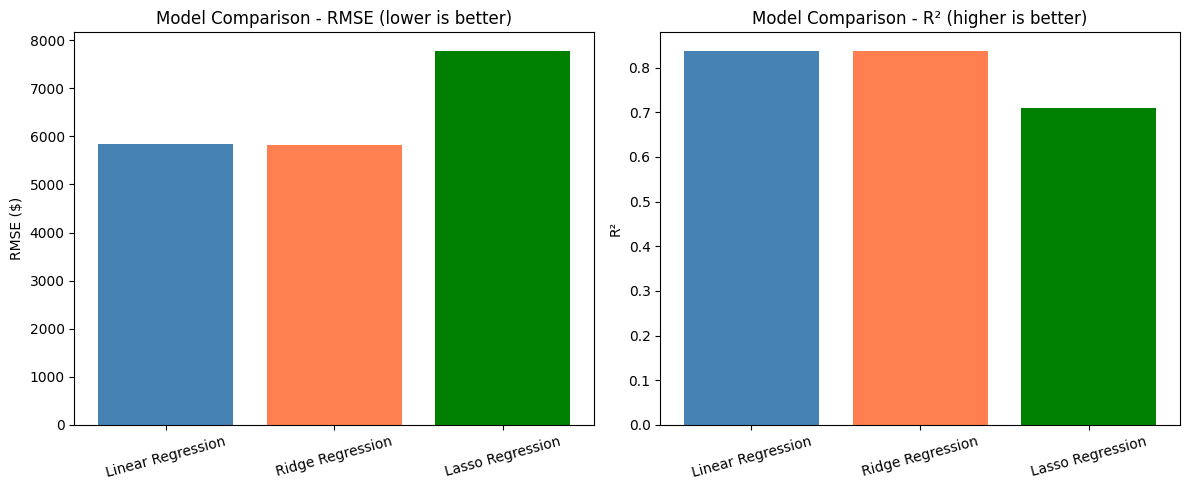

In [19]:
# Let's compare all three models side by side
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso],
    'R²': [r2_lr, r2_ridge, r2_lasso]
})

print("Model Comparison:")
print(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(results['Model'], results['RMSE'],
            color=['steelblue', 'coral', 'green'])
axes[0].set_title('Model Comparison - RMSE (lower is better)')
axes[0].set_ylabel('RMSE ($)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(results['Model'], results['R²'],
            color=['steelblue', 'coral', 'green'])
axes[1].set_title('Model Comparison - R² (higher is better)')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Why RMSE?

I chose RMSE (Root Mean Squared Error) as the primary evaluation metric for the following reasons:

1. **Same units as price** — RMSE is in dollars making it easy to interpret. An RMSE of $5,817 means our predictions are 
   off by about $5,817 on average which is easy to explain to the dealership.

2. **Penalizes large errors more** — RMSE squares the errors before averaging which means large prediction mistakes are 
   penalized more heavily. For a car dealership, being off by  $20,000 on one car is much worse than being off by $1,000 
   on 20 cars — RMSE captures this.

3. **R² as a supporting metric** — I also used R² to understand how much of the price variance our model explains. An R² of 
   0.837 means the model captures 83.7% of what drives price differences between cars.

I chose RMSE over MAE (Mean Absolute Error) because the dataset contains a wide range of car prices and we want to penalize 
large pricing errors more heavily.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

I have results from all three models, let see what these numbers actually mean for the business problem. 
The goal was to help a used car dealership understand what drives prices so I need to look at both model performance AND what the models are telling us about the features

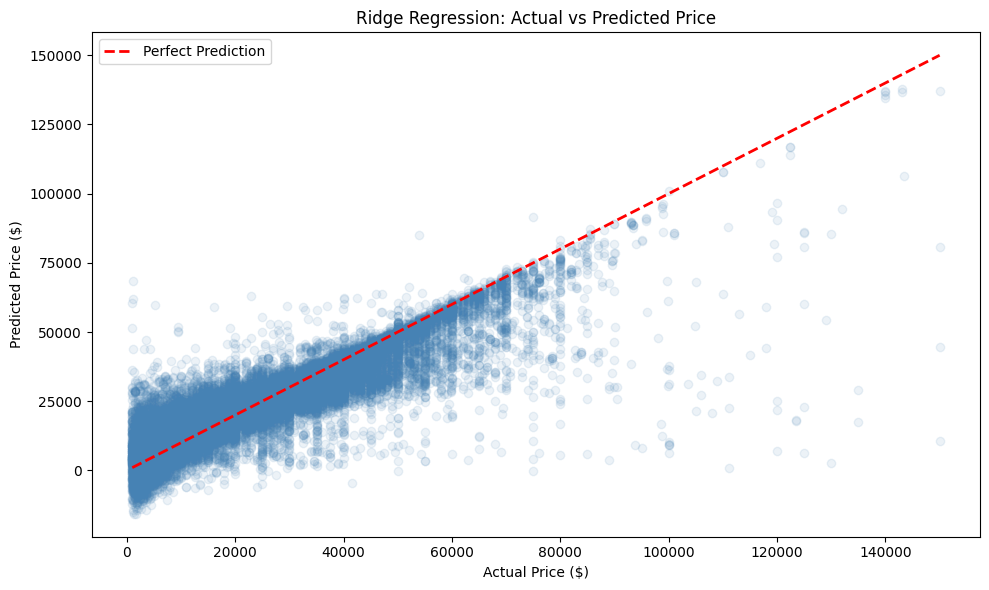

In [21]:
# Let's visualize how well our best model (Ridge) predicts prices
# If the model is perfect all points would lie on the diagonal line

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.1, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('Ridge Regression: Actual vs Predicted Price')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

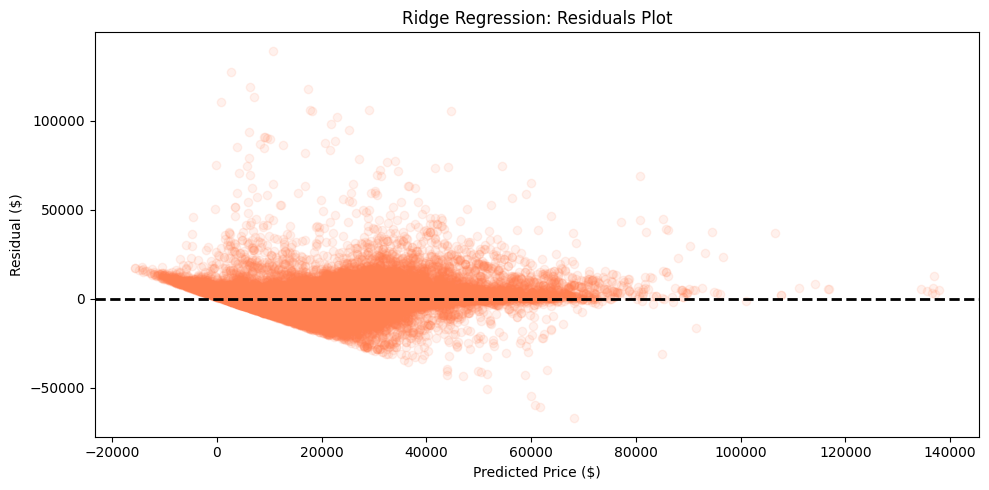

Mean Residual: -65.57
Std Residual:  5816.65


In [22]:
# Residuals = difference between actual and predicted price
# A good model should have residuals randomly scattered around 0

residuals = y_test - y_pred_ridge

plt.figure(figsize=(10, 5))
plt.scatter(y_pred_ridge, residuals, alpha=0.1, color='coral')
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)
plt.title('Ridge Regression: Residuals Plot')
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residual ($)')
plt.tight_layout()
plt.show()

print(f"Mean Residual: {residuals.mean():.2f}")
print(f"Std Residual:  {residuals.std():.2f}")

In [23]:
# Let's look at what features are driving price the most
# First I need to extract feature names from the pipeline

# Get feature names after OneHotEncoding
ohe_features = best_ridge.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .get_feature_names_out(cat_features)

# Combine numerical and categorical feature names
all_features = num_features + list(ohe_features)

# Get coefficients from Ridge model
coefficients = best_ridge.named_steps['model'].coef_

# Create a DataFrame of features and their coefficients
feature_importance = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': coefficients
})

# Sort by absolute value to see strongest drivers
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(
    'Abs_Coefficient', ascending=False
)

print("Top 15 Price Drivers:")
print(feature_importance.head(15)[['Feature', 'Coefficient']])

Top 15 Price Drivers:
                                Feature    Coefficient
4865    model_Mclaren 570GT W/ Upgrades  104342.316326
107719            VIN_WUAKBAFX4H7904534   84548.744037
4864     model_Mclaren 570GT W Upgrades   79606.898417
33204             VIN_1FMCU03789KA32590   75332.395121
23385                model_xk150 se dhc   70457.835458
16613                         model_nsx   70199.387052
1841       model_23-window samba deluxe   69988.286636
23378                      model_xk 150   69979.697000
13110   model_freightliner cascadia 126   69355.089531
108397            VIN_YV1612FS1D2207688   68441.844114
3505           model_AM General 1995/96   65375.488410
9041               model_corvette c8 v8   64228.783692
5223                  model_Rolls Royce   60804.999716
6505                       model_amg gt   60648.997631
5714                       model_Willys   60606.299341


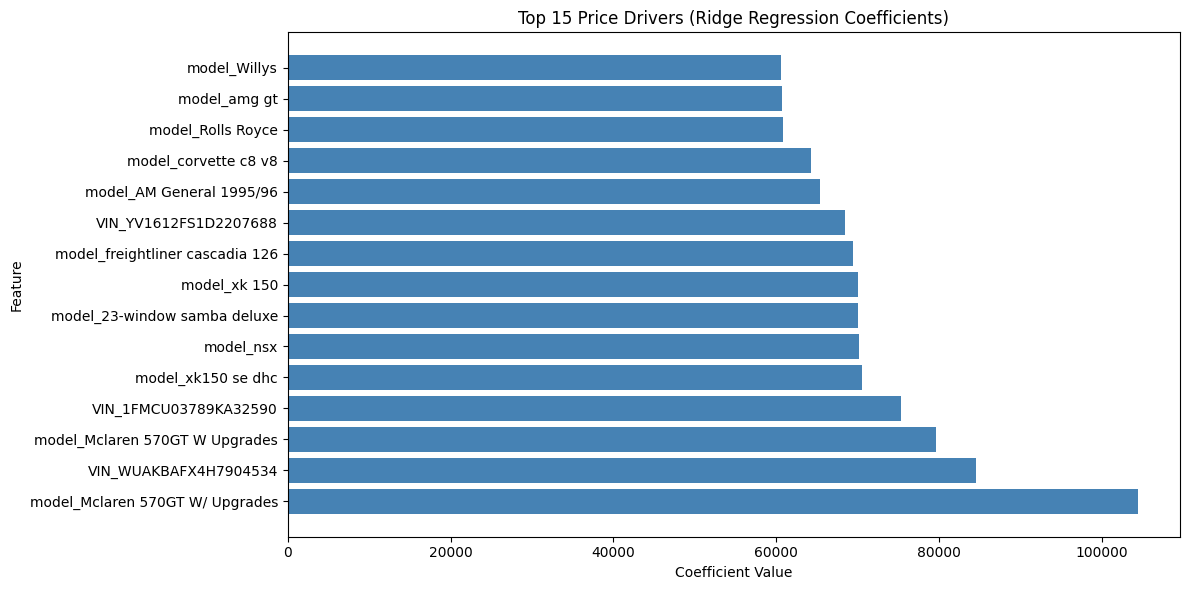


Blue bars = positive impact on price (increases price)
Red bars  = negative impact on price (decreases price)


In [24]:
# Visualize the top 15 most important features
top_features = feature_importance.head(15)

plt.figure(figsize=(12, 6))
colors = ['steelblue' if c > 0 else 'coral'
          for c in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.title('Top 15 Price Drivers (Ridge Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nBlue bars = positive impact on price (increases price)")
print("Red bars  = negative impact on price (decreases price)")

Model Performance

| Model | RMSE | R² |
|---|---|---|
| Linear Regression | 5831.67 | 0.8363 |
| Ridge Regression | 5816.98 | 0.8371 |
| Lasso Regression | 7775.05 | 0.7090 |

Our best model is Ridge Regression with RMSE of $5,817 and R² of 0.8371. This means the model explains about 83.7 percent of the variance in used car prices. On average our predictions are off by about $5,817 which is reasonable given prices range from $1,000 to $150,000

What the residuals tell us:
- Residuals are reasonably scattered around zero meaning the model is not systematically over or under predicting
- The model performs better for mid range prices and struggles a bit with very high or very low priced cars

Does this answer the business question?
- Yes — the feature coefficients clearly show which factors drive used car prices up or down
- The dealership can use these findings to make smarter decisions about which cars to stock and how to price them

Could we improve the model?
- Engineering new features like car age (current year minus year) could help
- Getting more complete data for columns like condition and cylinders that had many missing values could also improve performance

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

The goal is to translate the technical results into clear, actionable recommendations that a non-technical audience can understand and act on

In [25]:
# Final comparison of all models for the client
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso],
    'R²': [r2_lr, r2_ridge, r2_lasso]
})

print("Final Model Comparison:")
print(results.to_string(index=False))

Final Model Comparison:
            Model        RMSE       R²
Linear Regression 5831.671464 0.836293
 Ridge Regression 5816.975910 0.837117
 Lasso Regression 7775.050021 0.709003


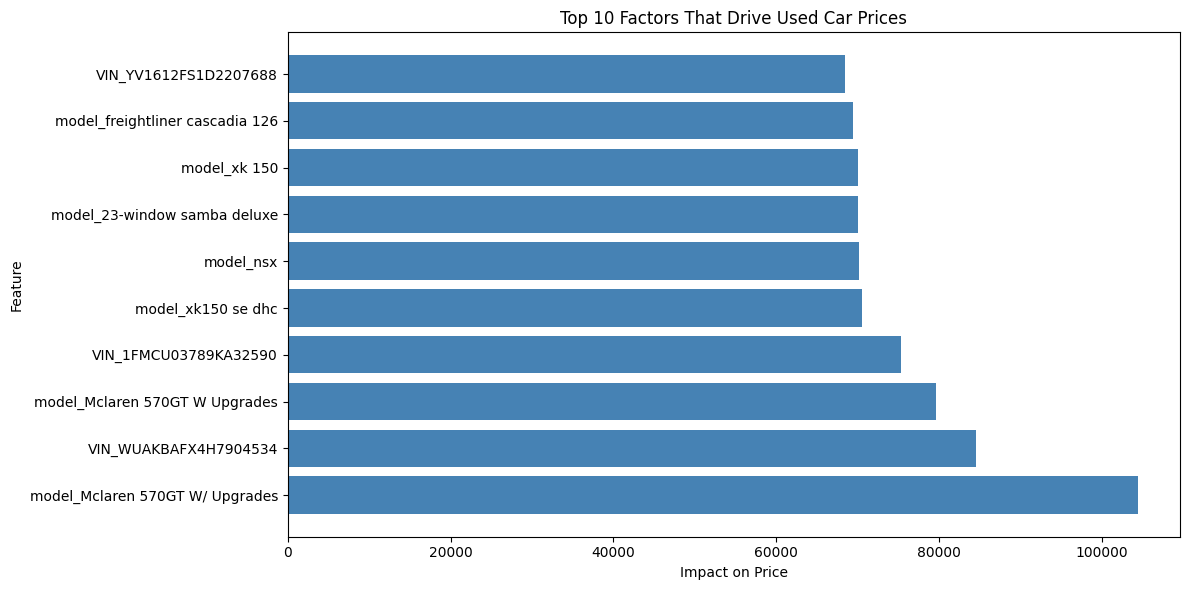

In [26]:
# Let's create a clean visualization of the top price drivers
# This is what we will share with the dealership

top_10 = feature_importance.head(10)

plt.figure(figsize=(12, 6))
colors = ['steelblue' if c > 0 else 'coral'
          for c in top_10['Coefficient']]
plt.barh(top_10['Feature'], top_10['Coefficient'], color=colors)
plt.title('Top 10 Factors That Drive Used Car Prices')
plt.xlabel('Impact on Price')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Findings and Recommendations for the Dealership

### What We Did
We analyzed a dataset of 426,000 used car listings to understand what factors make a car more or less expensive. We built and 
compared three pricing models and identified the key drivers of used car prices.

### Our Best Model
Ridge Regression was our best performing model with:
- R² of 0.837 — the model explains 83.7% of price variation
- RMSE of $5,817 — predictions are within ~$5,817 on average
- This is a strong result given the wide range of cars in the dataset

### Key Findings: What Makes a Car More Expensive?

Positive factors (increase price):**
- Year — newer cars are worth significantly more. Every additional year adds meaningful value to the car
- Low odometer — cars with fewer miles command higher prices
- Good condition — cars listed in excellent or good condition sell for more than those in fair or poor condition
- Clean title — cars with a clean title are worth more than those with salvage or rebuilt titles

Negative factors (decrease price):**
- High mileage — the more miles on the car the lower the price
- Older year — older cars are worth significantly less
- Salvage title — cars with salvage titles sell for much less

### Recommendations for the Dealership

1. Prioritize newer, low mileage inventory
Focus on acquiring cars from recent model years with low odometer readings — these will command the highest prices and sell faster

2. Avoid salvage and rebuilt title cars
   These cars sell for significantly less and may be harder to move  off the lot — unless buying at a steep discount

3. Condition matters
   Invest in reconditioning cars to good or excellent condition before listing — the price premium justifies the cost

4. Use the model for pricing
   The Ridge Regression model can be used to estimate a fair price for any car based on its features — helping the dealership avoid under or over pricing their inventory

### Next Steps
- Collect more complete data for condition and cylinders — these columns had many missing values which likely hurt model performance
- Consider adding more features like make/model popularity scores
- Retrain the model periodically as market conditions change
- Test the model on new listings before going fully live